# Modelos de Clasificación

En este notebook se detallan las etapas del proyecto y los modelos entrenados en cada una de ellas.

### 1. Carga y Preparación de Datos

In [1]:
# =======================================================================================================
# CARGA
# =======================================================================================================

import pandas as pd
import sys

sys.path.append('..')

from src.vectorize import vectorization
from src.model import train, evaluation

df = pd.read_csv("../data/english_comments.csv")

df.head(3)

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers dont even have cont...,negative
2,i will forever acknowledge this channel with t...,positive


In [2]:
# =======================================================================================================
# VECTORIZACIÓN
# =======================================================================================================

X_train, X_test, y_train, y_test = vectorization(df['Comment'], df['Sentiment'])

print("----- Ejemplo ", "-" * 50)
print("-> Comentario como Texto: ", df['Comment'][0])
print("-> Comentario Vectorizado: ", X_train[0].toarray())


Total comentarios para entrenamiento: 12452 (80.0% del total)
66.0% positivos
20.0% neutros
14.000000000000002% negativos

Total comentarios para evaluación: 3114 (20.0% del total)
66.0% positivos
20.0% neutros
14.000000000000002% negativos

----- Ejemplo  --------------------------------------------------
-> Comentario como Texto:  lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use it even if they wanted to as each successive iphone incorporated the technology and older iphones were replaced the number of people who could use the technology increased
-> Comentario Vectorizado:  [[0. 0. 0. ... 0. 0. 0.]]


### 2. Métodos Basados en Naive Bayes

En esta sección se entrenan y evalúan dos modelos basados en Naive Bayes:

* **MultinomialNB:** se inicia con los parámetros usados en el proyecto anterior para partir del mismo punto.

* **ComplementNB:** alternativa que toma en cuenta la desbalance de datos (problema principal del dataset).

----- Modelo MultinomialNB  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.55      0.50      0.52       440
      Neutro       0.53      0.49      0.51       625
    Positivo       0.85      0.89      0.87      2049

    accuracy                           0.75      3114
   macro avg       0.64      0.62      0.63      3114
weighted avg       0.74      0.75      0.75      3114



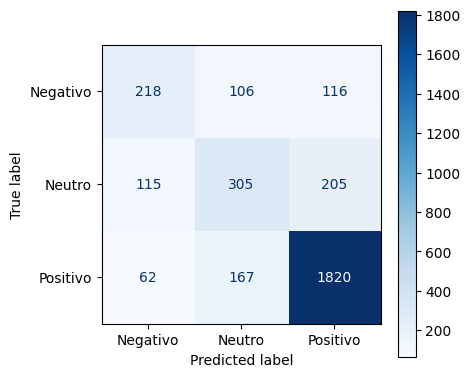

In [14]:
# =======================================================================================================
# MODELO NAIVE BAYES: MultinomialNB
# =======================================================================================================

from sklearn.naive_bayes import MultinomialNB

nbm_clf = MultinomialNB(class_prior=[1/3, 1/3, 1/3], alpha = 0.3)

print("----- Modelo MultinomialNB ", "-" * 50, "\n")

nbm_results, nbm_accuracy = train(nbm_clf, X_train, X_test, y_train, y_test)
nbm_report = evaluation(y_test, nbm_results)

----- Modelo ComplementNB  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.53      0.55      0.54       440
      Neutro       0.54      0.47      0.50       625
    Positivo       0.86      0.89      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.64      0.64      0.64      3114
weighted avg       0.75      0.76      0.75      3114



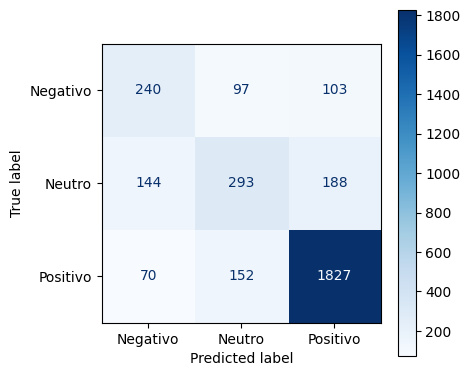

In [15]:
# =======================================================================================================
# MODELO NAIVE BAYES (Alternativa): ComplementNB
# =======================================================================================================

from sklearn.naive_bayes import ComplementNB

nbc_clf = ComplementNB(class_prior=[1/3, 1/3, 1/3], alpha=0.3)

print("----- Modelo ComplementNB ", "-" * 50, "\n")
nbc_results, nbc_accuracy = train(nbc_clf, X_train, X_test, y_train, y_test)
nbc_report = evaluation(y_test, nbc_results)

En ambos casos se obtienen resultados muy parecidos, siendo los del modelo ComplementNB ligeramente mejores. En general podemos observar:

* El porcentaje de acierto general ronda el 63%-64%, indicando que el modelo cumple su función pero no es del todo fiable.

* Ambos modelos mantienen una precision por clase media superior al 60%, lo que indica que cuando predicen una clase no fallan en exceso. Sin embargo el recall es más bajo y llega a caer por debajo del 50% en la clase neutra, lo que significa que ambos modelos tienen dificultades para detectar el total de comentarios de cada clase. El problema es especialmente pronunciado en MultinomialNB, donde el desbalance de clases arrastra las predicciones hacia la clase negativa.

* Seguimos con el mismo problema de desbalance y consecuente inclinación hacia la clase positiva. El modelo ComplementNB parece mejorar el problema aunque no significativamente.

### 3. Modelos no Bayesianos

Ya hemos llegado al techo del problema para Bayes. Pasamos ahora a resolverlo usando métodos de regresión lineal. Concretamente:

* **LogisticRegression:** aplica una transformación sigmoidal a la regresión (para obtener probabilidades) y busca los pesos mediante máxima verosimilitud.

* **LinearSVC:** busca el hiperplano más alejado de los grupos, de modo que queden perfectamente separados.

----- Modelo con Regresión Logística  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.47      0.57      0.52       440
      Neutro       0.52      0.65      0.58       625
    Positivo       0.92      0.81      0.86      2049

    accuracy                           0.74      3114
   macro avg       0.64      0.68      0.65      3114
weighted avg       0.78      0.74      0.75      3114



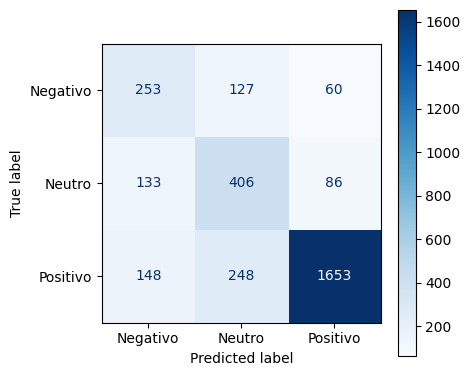

In [5]:
# =======================================================================================================
# DESBALANCE DE CLASES I. MODELOS BASADOS EN LA REGRESIÓN
# =======================================================================================================

# Logistic regression
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(class_weight="balanced")

print("----- Modelo con Regresión Logística ", "-" * 50, "\n")

log_results, log_accuracy = train(log_clf, X_train, X_test, y_train, y_test)
log_report = evaluation(y_test, log_results)


* El porcentaje de acierto general sube al 74%, una mejora notable respecto a los modelos de Bayes.

* La introducción de `class_weight='balanced'` redistribuye las predicciones de forma más equitativa entre las tres clases. El recall mejora significativamente respecto a Naive Bayes, especialmente en negativo y neutro, aunque también detecta más falsos positivos.

* El macro F1 sube a 0.65, confirmando que el modelo gestiona mejor el desbalance que Naive Bayes. Sin embargo la clase positiva sigue siendo la mejor clasificada con diferencia (F1 0.86), mientras que negativo y neutro se mantienen por debajo de 0.60 indicando que el desbalance sigue limitando el rendimiento en las clases minoritarias.

Vamos ahora con **LinearSVC**:

----- Modelo con Regresión Lineal  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.52      0.48      0.50       440
      Neutro       0.56      0.54      0.55       625
    Positivo       0.87      0.89      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.65      0.64      0.64      3114
weighted avg       0.76      0.76      0.76      3114



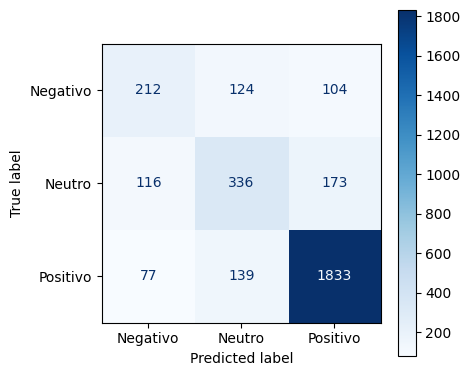

In [6]:
# Regresión lineal
from sklearn.svm import LinearSVC

lin_clf = LinearSVC(class_weight="balanced")

print("----- Modelo con Regresión Lineal ", "-" * 50, "\n")

lin_results, lin_accuracy = train(lin_clf, X_train, X_test, y_train, y_test)
lin_report = evaluation(y_test, lin_results)


* El porcentaje de acierto general sube ligeramente al 76%, prácticamente igual que la regresión logística.

* A diferencia de la regresión logística, LinearSVC muestra un comportamiento más equilibrado entre precision y recall dentro de cada clase, de modo que el modelo parece no tener una tendencia clara a sobrepredicir ni a infrapredicir ninguna clase en particular.

* El macro F1 es de 0.64, prácticamente idéntico al de la regresión logística (0.65). Ambos modelos están en el mismo techo, confirmando que la limitación no está en el algoritmo sino en la representación del texto mediante TF-IDF.

Otra alternativa es **RandomForest**: toma una muestra aleatoria para cada árbol de decisión y clasifican el elemento en la clase más votada.

----- Modelo con RandomForest  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.82      0.09      0.17       440
      Neutro       0.62      0.35      0.44       625
    Positivo       0.73      0.97      0.83      2049

    accuracy                           0.72      3114
   macro avg       0.72      0.47      0.48      3114
weighted avg       0.72      0.72      0.66      3114



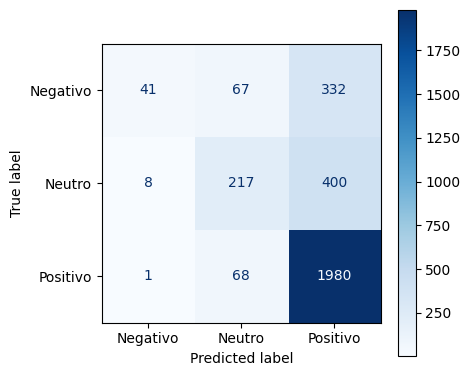

In [7]:
# =======================================================================================================
# DESBALANCE DE CLASES II. MODELOS RandomForest
# =======================================================================================================

# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(class_weight="balanced")

print("----- Modelo con RandomForest ", "-" * 50, "\n")

rf_results, rf_accuracy = train(rf_clf, X_train, X_test, y_train, y_test)
rf_report = evaluation(y_test, rf_results)

* El porcentaje de acierto general es del 72%, inferior a los modelos lineales a pesar de ser un modelo más complejo.

* El resultado más llamativo es el recall de la clase negativa, de un 0.09, lo que significa que el modelo apenas detecta 1 de cada 10 comentarios negativos reales. Sin embargo su precision es alta (0.82), indicando que cuando predice negativo casi siempre acierta. Es el patrón opuesto al que veíamos en Naive Bayes sin corrección de desbalance.

* El macro F1 cae a 0.48, significativamente por debajo de los modelos lineales. 

Se confirma lo esperado teóricamente: Random Forest maneja mal los vectores TF-IDF sparse porque el muestreo aleatorio de features en cada nodo tiene alta probabilidad de seleccionar features con valor cero, produciendo splits sin información útil.

### 4. Modificaciones del Modelo de Regresión Logística

Puesto que el modelo LogisticRegression es el que mejores resultados ha devuelto (muy cerca de LinearSVC), vamos a modificar sus parámetros hasta llegar a la mejor solución posible.

----- Modelo con Regresión Logística Mejorada  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.55      0.52      0.54       440
      Neutro       0.62      0.52      0.57       625
    Positivo       0.86      0.91      0.89      2049

    accuracy                           0.78      3114
   macro avg       0.68      0.65      0.66      3114
weighted avg       0.77      0.78      0.77      3114



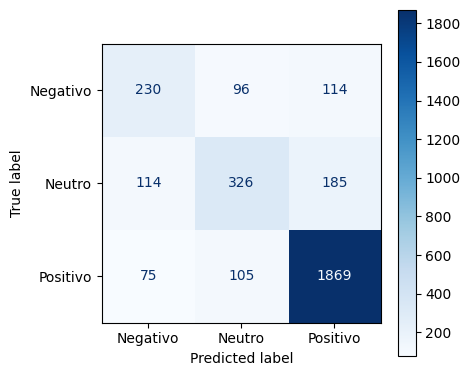

In [10]:
# =======================================================================================================
# MODIFICACIONES DEL MODELO DE REGRESIÓN LOGÍSTICA
# =======================================================================================================

improved_log_clf = LogisticRegression(class_weight={'negative': 2.5, 'neutral': 1.5, 'positive': 1}, C=2.5)

print("----- Modelo con Regresión Logística Mejorada ", "-" * 50, "\n")

improved_log_results, improved_log_accuracy = train(improved_log_clf, X_train, X_test, y_train, y_test)
improved_log_report = evaluation(y_test, improved_log_results)


Modelo inicial

            precision    recall  f1-score   support

Positivo       0.47      0.57      0.52       440
Neutro         0.52      0.65      0.58       625
Negativo       0.92      0.81      0.86      2049

accuracy                           0.74      3114
macro avg      0.64      0.68      0.65      3114
weighted avg   0.78      0.74      0.75      3114


Para {'positive': 0.5, 'neutral': 1.5, 'negative': 2.2} y C=1

            precision    recall  f1-score   support

Positivo        0.48      0.58      0.52       440
Neutro          0.53      0.63      0.58       625
Negativo        0.92      0.82      0.87      2049

accuracy                            0.75      3114
macro avg       0.64      0.68      0.66      3114
weighted avg    0.78      0.75      0.76      3114


Para {'positive': 1.5, 'neutral': 1.5, 'negative': 2.2} y C=1 (Mod. 1)

            precision    recall  f1-score   support

Positivo        0.60      0.46      0.52       440
Neutro          0.65      0.41      0.50       625
Negativo        0.82      0.95      0.88      2049

accuracy                            0.77      3114
macro avg       0.69      0.61      0.63      3114
weighted avg    0.75      0.77      0.75      3114


Para {'positive': 1.5, 'neutral': 1.5, 'negative': 2.2} y C=2.5 (Mod. 2)

           precision    recall  f1-score   support

Positivo       0.58      0.48      0.53       440
Neutro         0.62      0.47      0.54       625
Negativo       0.84      0.94      0.88      2049

accuracy                           0.78      3114
macro avg      0.68      0.63      0.65      3114
weighted avg   0.76      0.78      0.76      3114


Para {'positive': 1, 'neutral': 1.5, 'negative': 2.5} y C=2.5 (Mod. 3)

            precision    recall  f1-score   support

Positivo       0.55      0.52      0.54       440
    Neutro     0.62      0.52      0.57       625
Negativo       0.86      0.91      0.89      2049

accuracy                            0.78      3114
macro avg       0.68      0.65      0.66      3114
weighted avg    0.77      0.78      0.77      3114

----- Modelo con Regresión Lineal  -------------------------------------------------- 

              precision    recall  f1-score   support

    Negativo       0.52      0.53      0.53       440
      Neutro       0.60      0.50      0.54       625
    Positivo       0.86      0.90      0.88      2049

    accuracy                           0.77      3114
   macro avg       0.66      0.64      0.65      3114
weighted avg       0.76      0.77      0.76      3114



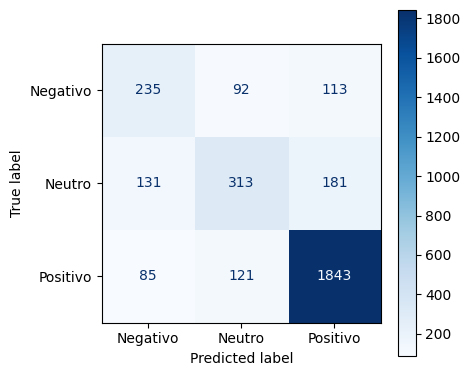

In [39]:
# Regresión lineal
improved_lin_clf = LinearSVC(class_weight={'negative': 3, 'neutral': 1, 'positive': 0.5}, C=1)

print("----- Modelo con Regresión Lineal ", "-" * 50, "\n")

improved_lin_results, improved_lin_accuracy = train(improved_lin_clf, X_train, X_test, y_train, y_test)
improved_lin_report = evaluation(y_test, improved_lin_results)

class_weight={'negative': 3, 'neutral': 1.5, 'positive': 0.5}, C=1
 
              precision    recall  f1-score   support

    Negativo       0.52      0.50      0.51       440
      Neutro       0.57      0.53      0.55       625
    Positivo       0.87      0.89      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.65      0.64      0.65      3114
weighted avg       0.76      0.76      0.76      3114


class_weight={'negative': 3, 'neutral': 1, 'positive': 0.5}, C=1

              precision    recall  f1-score   support

    Negativo       0.52      0.53      0.53       440
      Neutro       0.60      0.50      0.54       625
    Positivo       0.86      0.90      0.88      2049

    accuracy                           0.77      3114
   macro avg       0.66      0.64      0.65      3114
weighted avg       0.76      0.77      0.76      3114


